In [ ]:
# 20th July, 2026
# Learned to make a simple Linear Regression Model -> Salary Prediction

In [ ]:
# Step 1: Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder # to convert text into numbers
from sklearn.linear_model import LogisticRegression # our model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # to evaluate our model

In [ ]:
csv_path = "/content/Salary_Data.csv"
df = pd.read_csv(csv_path)
print(df.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [ ]:
print("\Missing Values per column:")
print(df.isnull().sum())

\Missing Values per column:
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_664/2586205889.py:1: SyntaxWarning: invalid escape sequence '\M'
  print("\Missing Values per column:")


In [ ]:
df = df.dropna()

In [ ]:
# check if all null values are removed or not
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [ ]:
# 3 Encode Categorical Columns
categorical_cols = ["Gender", "Education Level", "Job Title"]
encoders = {} # column name: fitted LabelEncoder

In [ ]:
for col in categorical_cols:
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoders[col] = le # saving the fitted encoder for later use

In [ ]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [ ]:
# Defining featurers (x) and target (y)
x = df[["Age", "Gender", "Education Level", "Job Title", "Years of Experience"]] # featrues
y = df["Salary"] # target

In [ ]:
# Training set : used to teach the model
# Test Set: used to evaluate the model
# Train/Test Split: Ususally 80:20 in the normal, but there is no hard and fast rule

# Why not train on 100% of the data?
# will be learned later

In [ ]:
# Splitting data across training and testing set

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
# In machine learning, test_size = 0.2 means 20% of your dataset is reserved for testing
# the model's accuracy, while the remaining 80% is used for training.
# This common split prevents overfitting and ensures your model performs well on unseen data

# In machine learning, random_state=42 is a standard parameter used to initialize the pseudo-random
# number generator. It ensures that operations like data shuffling and train/test splits yield the
# exact same results every time you run your code

In [ ]:
x_train.shape[0]

298

In [ ]:
x_train

,Age,Gender,Education Level,Job Title,Years of Experience
193,34.0,1,0,141,7.0
75,37.0,1,0,96,10.0
84,29.0,0,0,56,2.0
363,33.0,1,0,65,5.0
16,33.0,0,1,83,7.0
...,...,...,...,...,...
71,39.0,0,0,98,11.0
106,30.0,0,0,20,3.0
272,37.0,1,0,118,8.0
350,44.0,0,2,115,16.0


In [ ]:
x_test.shape[0]

75

In [ ]:
x_test

,Age,Gender,Education Level,Job Title,Years of Experience
329,48.0,1,1,29,21.0
33,39.0,0,0,84,10.0
15,44.0,1,0,89,16.0
316,34.0,0,1,117,6.0
57,43.0,1,2,116,17.0
...,...,...,...,...,...
94,33.0,1,0,3,7.0
196,41.0,0,0,132,11.0
313,33.0,1,0,49,4.0
294,45.0,0,1,122,14.0


In [ ]:
y_test

,Salary
329,180000.0
33,65000.0
15,125000.0
316,80000.0
57,140000.0
...,...
94,75000.0
196,90000.0
313,60000.0
294,140000.0


In [ ]:
# training the model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
print("Intercept (b0):", model.intercept_)
print("Coefficients (b1..bn) for [Age, Gender, Education Level, Job Title, Years of Experience]:")
print(model.coef_)

Intercept (b0): -64275.44417198711
Coefficients (b1..bn) for [Age, Gender, Education Level, Job Title, Years of Experience]:
[ 3383.45772431  7275.180023   15062.97827322    45.92361331
  2182.53415593]


**Evaluating the Model on the Test Data**

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(mse) # error
print(mae) # error
print(r2) # performance

249075656.42722148
10928.921486231397
0.8961138207821864


#Visualize the actual vs predicted salary


Saved plot as 'actual_vs_predicted_salary.png'


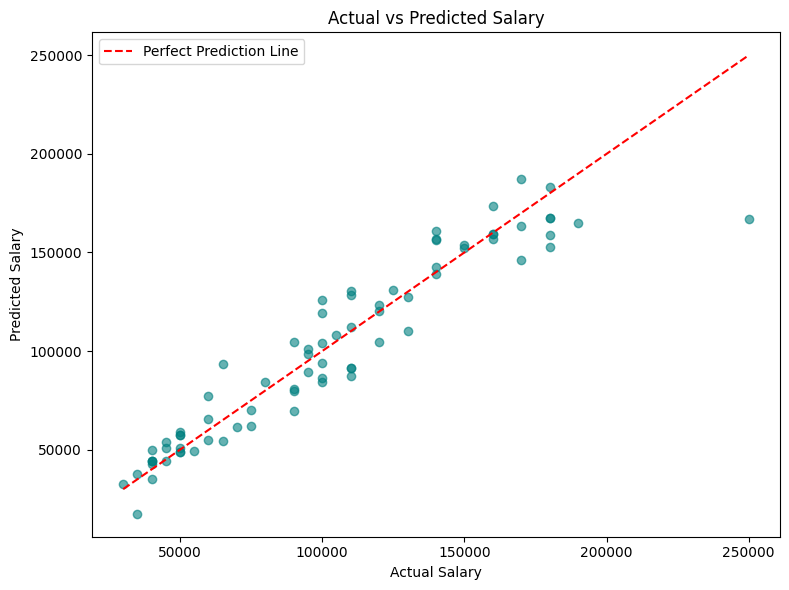

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal")
plt.plot(
    [y_test.min(), y_test.max()], # x-cordinate
    [y_test.min(), y_test.max()], # y-cordinate
    color="red",
    linestyle="--",
    label="Perfect Prediction Line",
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.legend()
plt.tight_layout() # automatically adjusts subplot padding and spacing
plt.savefig("actual_vs_predicted_salary.png")
print("\nSaved plot as 'actual_vs_predicted_salary.png'")

#prediction using cusom input

In [ ]:
def predict_salary(age, gender, education_level, job_title, years_of_experience):
    try:
        gender_encoded = encoders["Gender"].transform([gender])[0]
        education_encoded = encoders["Education Level"].transform([education_level])[0]
        job_encoded = encoders["Job Title"].transform([job_title])[0]
    except ValueError as e:
        raise ValueError(
            f"Unseen category provided: {e}. "
            f"Value must be one that exists in the training dataset."
        )

    # Build a single-row DataFrame with the SAME column order used during training
    input_data = pd.DataFrame([[age, gender_encoded, education_encoded, job_encoded, years_of_experience]],
        columns=["Age", "Gender", "Education Level", "Job Title", "Years of Experience"],
    )

    predicted_salary = model.predict(input_data)[0]
    return predicted_salary

In [ ]:
custom_prediction = predict_salary(30, "Male", "Bachelor's", "Data Scientist", 5)
print(f"\nPredicted Salary: {custom_prediction:,.2f}")


Predicted Salary: 56,288.69


In [ ]:
custom_prediction = predict_salary(30, "Male", "Bachelor's", "Software Engineer", 10)
print(f"\nPredicted Salary: {custom_prediction:,.2f}")


Predicted Salary: 73,630.66


In [ ]:
custom_prediction = predict_salary(30, "Female", "Bachelor's", "Data Scientist", 10)
print(f"\nPredicted Salary: {custom_prediction:,.2f}")


Predicted Salary: 59,926.18


In [ ]:
# data bias: systematic error where data skews results and fails to reflect real-world population.

In [ ]:
from logging import fatal
# Workflow of ML/ Stages of ML
# Here, we did
'''
  1. Data Collection
  2. Data Cleaning/Pre-processing
  3. Define target/features
  4. Split the training and testing set (80-20, 75-25)
  5. Train the model
  6. Evaluate - loss (mse, mae)/performance(r2, adjusted-r2)
  7. Testing on the custom/unseen data
'''

# Next class, we will discuss: Gradient Descent(Optimization Technique)